# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
G = 6.67*10**-11
d_EM = float(3.8*10**8)
M_E = float(5.9*10**24)
M_M = float(7.3*10**22)
m_dot = 1.3 *10**4
m_naught = 2.8*10**6
m_f = 7.5*10**5
v_e = 2.4*10**3
g = 9.81
M_A = 5500

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def potential(x, y, M, x_M, y_M):
    '''
    Returns the gravitational potential at a distance r from mass M where G is the gravitational constant

    Args:
    x (float) -> x coordinate of location
    y (float) -> y coordinate of location
    M (float) -> mass
    x_M (float) -> x coordinate of mass
    y_M (float) -> y coordinate of mass

    Returns: 
    potential (float) 
    '''
    if not isinstance(M, float):
        raise TypeError(f'M is the wrong type: {type(M)}')
    if not isinstance(x_M, float):
        raise TypeError(f'x_M is the wrong type: {type(x_M)}')
    if not isinstance(y_M, float):
        raise TypeError(f'y_M is the wrong type: {type(y_M)}')
    x_r = x - x_M
    y_r = y - y_M
    r = np.sqrt(x_r**2 + y_r**2)
    r = np.where(np.isclose(r,0), np.nan, r)
    return -G*M/r

potential(2,1,1.0,1.0,1.0)

np.float64(-6.67e-11)

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

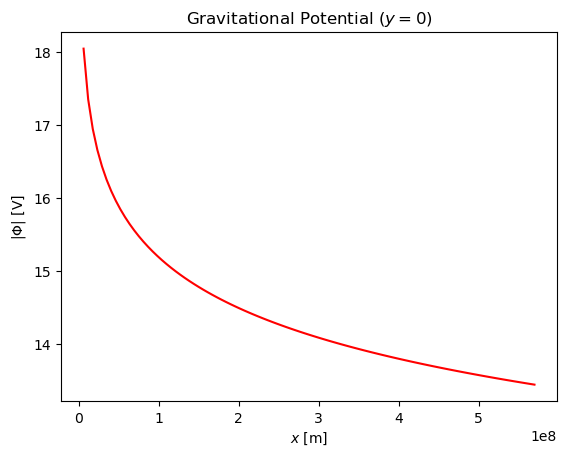

In [4]:
distance = 1.5*d_EM
x = np.linspace(0.0,distance,100)
y = 0.0

fig, ax = plt.subplots()
plot1 = ax.plot(x, np.log(np.abs(potential(x, y, M_E, 0.0, 0.0))), 'r')
ax.set_title('Gravitational Potential $(y=0)$')
ax.set_xlabel('$x$ [m]')
ax.set_ylabel(r'$|\Phi|$ [V]');

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

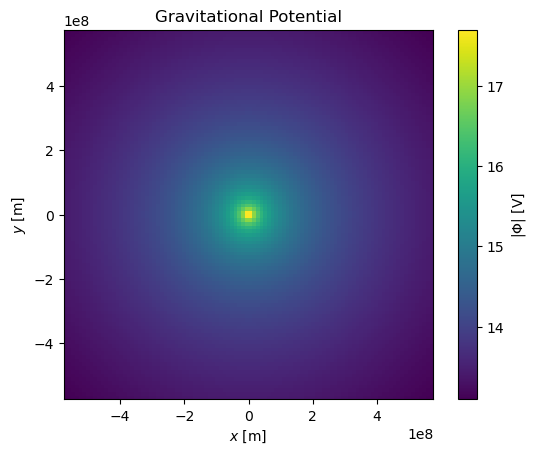

In [5]:
x_mesh = np.linspace(-distance,distance,100)
y_mesh = np.linspace(-distance,distance,100)
X, Y = np.meshgrid(x_mesh,y_mesh)

fig, ax = plt.subplots()
mesh1 = ax.pcolormesh(X, Y, np.log(np.abs(potential(X, Y, M_E, 0.0, 0.0))))
ax.set_title('Gravitational Potential')
ax.set_xlabel('$x$ [m]')
ax.set_ylabel('$y$ [m]')
ax.set_aspect('equal')
cbar = fig.colorbar(mesh1)
cbar.set_label(r'$|\Phi|$ [V]')

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

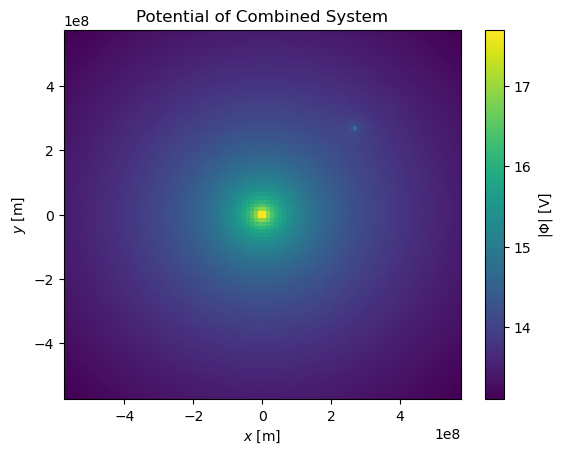

In [6]:
fig, ax = plt.subplots()
x_M = d_EM/np.sqrt(2)
y_M = d_EM/np.sqrt(2)

combined_system_potential = np.abs(potential(X, Y, M_E, 0.0, 0.0)) + np.abs(potential(X, Y, M_M, x_M, y_M))

# fig, ax = plt.subplots()
mesh2 = ax.pcolormesh(X, Y, np.log(combined_system_potential))
ax.set_title('Potential of Combined System')
ax.set_xlabel('$x$ [m]')
ax.set_ylabel('$y$ [m]')
cbar = fig.colorbar(mesh2)
cbar.set_label(r'$|\Phi|$ [V]')

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

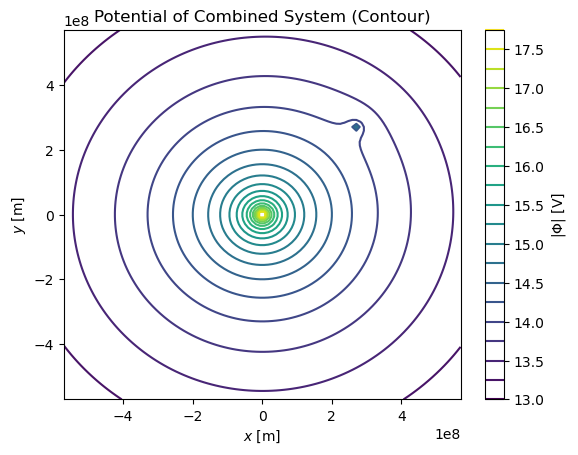

In [7]:
fig, ax = plt.subplots()
contour1 = ax.contour(X, Y, np.log(combined_system_potential), levels=20)
ax.set_title('Potential of Combined System (Contour)')
ax.set_xlabel('$x$ [m]')
ax.set_ylabel('$y$ [m]')
cbar = fig.colorbar(contour1)
cbar.set_label(r'$|\Phi|$ [V]')

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def g_force(M_1, m_2, x_1, y_1, x_2, y_2):
    """
    Returns the x and y components of the gravitational force exerted by M_1 on m_2
    
    Args:
    M_1 (float/int) -> mass of the source
    m_2 (float/int) -> mass of the target
    x_1 (float/int) -> x coordinate of the source
    y_1 (float/int) -> y coordinate of the source
    x_2 (float/array) -> x coordinate of target
    y_2 (float/array) -> y coordinate of target
    
    Returns:
    x and y components of gravitational force
    """
    if not isinstance(M_1, (float, int)):
        raise TypeError(f'M_1 is the wrong type: {type(M_1)}')
    if not isinstance(m_2, (float, int)):
        raise TypeError(f'm_2 is the wrong type: {type(m_2)}')
    if not isinstance(x_1, (float, int)):
        raise TypeError(f'x_1 is the wrong type: {type(x_1)}')
    if not isinstance(y_1, (float, int)):
        raise TypeError(f'y_1 is the wrong type: {type(y_1)}')
    x = x_2 - x_1
    y = y_2 - y_1
    r_21 = np.sqrt(x**2 + y**2)
    r_21 = np.where(np.isclose(r_21, 0), np.nan, r_21)
    theta = np.arctan2(y,x)
    F_21 = -G*M_1*m_2/(r_21**2)
    F_x = F_21*np.cos(theta)
    F_y = F_21*np.sin(theta)
    return F_x, F_y

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

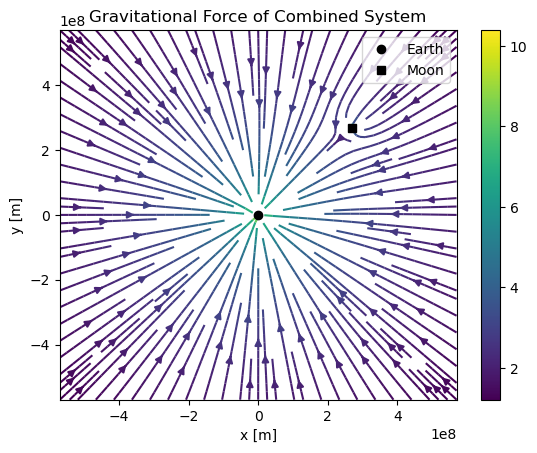

In [9]:
F_X_E, F_Y_E = g_force(M_E, M_A, 0, 0, X, Y)
F_X_M, F_Y_M = g_force(M_M, M_A, x_M, y_M, X, Y)
F_X = F_X_E + F_X_M
F_Y = F_Y_E + F_Y_M

fig, ax = plt.subplots()

magnitude = np.log(np.sqrt(F_X**2 + F_Y**2))
stream = ax.streamplot(X, Y, F_X, F_Y, color=magnitude, density=1.5)
ax.plot(0, 0, 'ko', label='Earth') 
ax.plot(x_M, y_M, 'ks', label='Moon')
ax.set_title('Gravitational Force of Combined System')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.legend(loc='upper right')
fig.colorbar(stream.lines)
cbar.set_label(r'$F$ [N]') #can't get to show up, worked for other one

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$|F_{moon}| = |F_{earth}| \rightarrow -G \frac{M_M M_A}{\vec{r}_{MA}^2} = -G \frac{M_E M_A}{\vec{r}_{EA}^2}\rightarrow \frac{M_M}{\vec{r}_{MA}^2} = \frac{M_E}{\vec{r}_{EA}^2}$

As a trivial result from linear algebra, we know that the balance point will lie on the line connecting the two bodies. Thus, we can say that the the distance from the earth to the moon is split up into two parts: the distance from the earth to the balance point, and the distance from the balance point to the moon. 

In other words, $d_{EM} = r_{EA} + r_{MA} \rightarrow r_{MA} = d_{EM} - r_{EA}$

$\frac{M_M}{(d_{EM} - r_{EA})^2} = \frac{M_E}{r_{EA}^2} \rightarrow \frac{\sqrt{M_M}}{d_{EM} - r_{EA}} = \frac{\sqrt{M_E}}{r_{EA}} \rightarrow r_{EA}\sqrt{M_M} = d_{EM}\sqrt{M_E} - r\sqrt{M_E} \rightarrow r_{EA} = d_{EM}\frac{\sqrt{M_E}}{\sqrt{M_E} + \sqrt{M_M}}$

Because of trigonometry and symmetry, $x_{EA}$ and $y_{EA}$ both equal $\frac{r}{\sqrt{2}}$

And your updated plot, including the balance point, goes in the cell below.

341962346.91181517


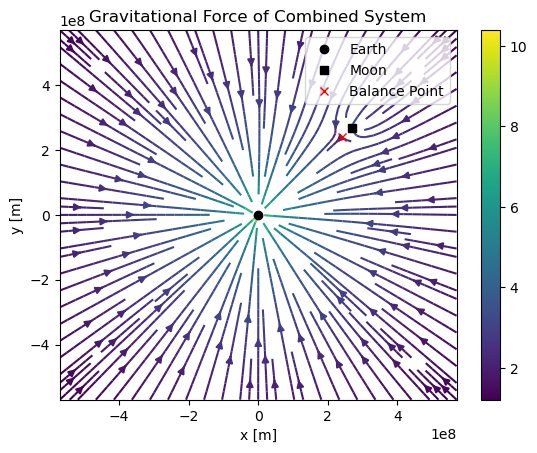

In [10]:
r_EA = d_EM*np.sqrt(M_E)/(np.sqrt(M_E)+np.sqrt(M_M))
x_EA = r_EA/np.sqrt(2)
y_EA = r_EA/np.sqrt(2)

print(r_EA)

fig, ax = plt.subplots()

stream = ax.streamplot(X, Y, F_X, F_Y, color=magnitude, density=1.5)
ax.plot(0, 0, 'ko', label='Earth') 
ax.plot(x_M, y_M, 'ks', label='Moon')
ax.plot(x_EA, y_EA, 'rx', label='Balance Point')
ax.set_title('Gravitational Force of Combined System')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.legend(loc='upper right')
cbar = fig.colorbar(stream.lines)

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is far closer to the Moon than the Earth. In fact, at a distance of $3.4 \times 10^8$, the balance point is almost $90\%$ of the way to the moon. This answer certainly makes sense, given the large disparities in the forces exerted by the respective bodies. The Earth, with a much greater mass, causes a much greater force when compared to the Moon. To put it intuitively, we can imagine the halfway point, where the force exerted by the Earth is much greater. For them to equal, we would have to move much closer to the Moon. We can also observe that the force lines on the graph start moving around the Moon at exactly the balance point. 

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (m_naught - m_f)/m_dot
print(f'Burn time: {T}')

Burn time: 157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t,v_e,m_naught,m_dot,g):
    '''Returns the change in a rocket's velocity at a time t, where v_e, m_0 and g are constants

    Args:
    t (float) -> current time

    Returns:
    change in velocity (float)
    '''
    if t > T or t < 0:
        return ValueError(f't is the wrong value: {t}')
    m_of_t = m_naught - m_dot*t
    return v_e*np.log(m_naught/m_of_t) - g*t

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
altitude, error = scipy.integrate.quad(delta_v, 0, T, args=(v_e,m_naught,m_dot,g))
print(f'Altitude: {altitude}')

Altitude: 74093.98013366401


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

There are a couple of factors which contribute to the discrepancies in the calculation. First, for $T$, the expected value is 160 s, while the calculated value is 157.7 s. This is an underestimate, and likely occurs because $\dot{m}$ is treated as a constant, when in reality, it is likely lower at certain points throughout the journey (during takeoff, landing, etc.). If the rate were sometimes lower, the time would increase.

As for $h$, the expected value is 70 km, while the calculated value is 74 km. This is an overestimate, and occurs because two factors are omitted from consideration. The first of these factors is the drag, which would draw away kinetic energy and reduce the velocity, resulting in a lower final altitude in real situations. The second factor that might be worth considering is that the flight path is not a straight up and down— it likely curves. These mean that the real altitude would in fact be shorter. 